# Evaluation


In [33]:
import sys
sys.path.append('../1_data_extraction')

import os
import numpy as np
import pandas as pd
import mlflow
import keras
import matplotlib.pyplot as plt

from crater_extraction import template_match_t, match_coords, filter_to_detectable, filter_edge_craters, truth_coords_for_patch, matchesExcludedCrater
from LRO_data_class import getSplitIndices, percentileNormalise, getLunarRobbinsLabels

In [34]:
params = {
    'dataset': 'alltiles',                # 'single' | 'alltiles'
    'channels': 'wac',                 # must match the trained run
    'n_filters': 32,
    'model': 'U-Net-v1',
    'training_sample_percentage': 10,                # must match the trained run. None = trained on all
    'seed': 42,                         # same sample across every run
    'n_sweep': 200,                     # val patches for the sweep
    'n_eval': 2000,                     # test patches for the metrics
}

In [35]:
if params['dataset'] == 'single':
    PATCHES_DIR = '../3_pre_processing/lunar_patches'
    LABELS_CSV = '../2_data_preparation/filtered_labels.csv'
else:
    PATCHES_DIR = '../3_pre_processing/lunar_patches_alltiles'
    LABELS_CSV = '../2_data_preparation/filtered_labels_alltiles.csv'

CHECKPOINT_DIR = '../4_training/checkpoints'

pct_tag = f"{params['training_sample_percentage']}pct" if params['training_sample_percentage'] else 'all'

run_name = f"{params['model']}_{params['channels']}_{params['n_filters']}f_s{params['seed']}_{pct_tag}"

# training writes one file per run, holding the best weights
CHECKPOINT = os.path.join(CHECKPOINT_DIR, f'{run_name}.keras')
HISTORY_CSV = os.path.join(CHECKPOINT_DIR, f'history_{run_name}.csv')


kept_labels = pd.read_csv(os.path.join(PATCHES_DIR, 'kept_labels.csv'), low_memory=False)
filtered_labels = pd.read_csv(LABELS_CSV)


train_idx, val_idx, test_idx = getSplitIndices(PATCHES_DIR)

In [36]:
model = keras.models.load_model(CHECKPOINT)

mlflow.set_tracking_uri('../4_training/mlruns')
mlflow.set_experiment('lunar-crater-detection')

with mlflow.start_run(run_name=f'eval-{run_name}') as run:
    mlflow.log_params(params)
    mlflow.log_param('checkpoint', CHECKPOINT)

    run_id = run.info.run_id


In [37]:
# wac_col/wac_row survive only in kept_labels, so the lat/lon -> pixel map is fitted from it
# per tile: each tile counts pixels from its own corner
if 'tile' not in kept_labels.columns:
    kept_labels['tile'] = 'single'

tile_craters = {}
tile_large = {}

# craters >= 10 km, the label cut. no ARC filter - existence is enough to excuse a detection
large_craters = getLunarRobbinsLabels()
large_craters = large_craters[large_craters['DIAM_CIRC_IMG'] >= 10]

for tile_name in kept_labels['tile'].dropna().unique():

    tile_rows = kept_labels[kept_labels['tile'] == tile_name]
    crater_rows = tile_rows.dropna(subset=['LON_CIRC_IMG', 'wac_col'])

    col_map = np.polyfit(crater_rows['LON_CIRC_IMG'], crater_rows['wac_col'], 1)
    row_map = np.polyfit(crater_rows['LAT_CIRC_IMG'], crater_rows['wac_row'], 1)

    # one fit per tile, applied to both crater sets
    tile_craters[tile_name] = (np.polyval(col_map, filtered_labels['LON_CIRC_IMG'].values), np.polyval(row_map, filtered_labels['LAT_CIRC_IMG'].values), filtered_labels['DIAM_CIRC_IMG'].values)
    tile_large[tile_name] = (np.polyval(col_map, large_craters['LON_CIRC_IMG'].values), np.polyval(row_map, large_craters['LAT_CIRC_IMG'].values), large_craters['DIAM_CIRC_IMG'].values)


print(f'{len(large_craters)} catalogue craters >= 10 km held back for false-positive exclusion')

24412 catalogue craters >= 10 km held back for false-positive exclusion


In [38]:
def safeDivide(numerator, denominator):
    return numerator / denominator if denominator else 0


def stackOrEmpty(parts, columns):
    return np.vstack(parts) if parts else np.empty((0, columns))


# 1000 patches per file - held between calls. keyed on the dir too, or switching
# dataset would serve stale patches
loaded = {}


def patchInput(patch_idx):

    file_num = int(patch_idx // 1000)
    position = patch_idx % 1000

    if loaded.get('file') != (PATCHES_DIR, file_num):
        loaded['wac'] = np.load(os.path.join(PATCHES_DIR, f'X_wac_{file_num}.npz'))['arr_0']
        loaded['dem'] = np.load(os.path.join(PATCHES_DIR, f'X_dem_{file_num}.npz'))['arr_0']
        loaded['mask'] = np.load(os.path.join(PATCHES_DIR, f'X_mask_{file_num}.npz'))['arr_0']
        loaded['file'] = (PATCHES_DIR, file_num)

    wac_patch = percentileNormalise(loaded['wac'][position])
    dem_patch = percentileNormalise(loaded['dem'][position])

    match params['channels']:
        case 'both':
            return np.stack([wac_patch, dem_patch], axis=-1)
        case 'wac':
            return wac_patch[..., None]
        case 'dem':
            return dem_patch[..., None]
        case _:
            raise ValueError(f"unknown channels {params['channels']}")


In [39]:

def patchTruth(patch_idx):
    row = kept_labels.iloc[patch_idx]
    
    tile_wac_col, tile_wac_row, tile_diameters = tile_craters[row['tile']]
    truth = truth_coords_for_patch(row['center_col'], row['center_row'], row['patch_lat'], tile_wac_col, tile_wac_row, tile_diameters)

    return filter_edge_craters(filter_to_detectable(truth))

def patchMask(patch_idx):
    patchInput(patch_idx)

    return loaded['mask'][patch_idx % 1000]

def patchLarge(patch_idx):
    # margin 600 px = 60 km, so rims crossing the patch from outside are caught
    row = kept_labels.iloc[patch_idx]
    large_col, large_row, large_diameters = tile_large[row['tile']]

    return truth_coords_for_patch(row['center_col'], row['center_row'], row['patch_lat'], large_col, large_row, large_diameters, margin=600)

## Threshold sweep

threshold 0.05: P 0.047  R 0.004  F1 0.008   | pixel P 0.019  R 0.999
threshold 0.1: P 0.218  R 0.096  F1 0.133   | pixel P 0.029  R 0.985
threshold 0.15: P 0.331  R 0.244  F1 0.281   | pixel P 0.042  R 0.958
threshold 0.2: P 0.423  R 0.406  F1 0.414   | pixel P 0.060  R 0.913
threshold 0.25: P 0.521  R 0.559  F1 0.540   | pixel P 0.083  R 0.850
threshold 0.3: P 0.611  R 0.693  F1 0.649   | pixel P 0.113  R 0.770
threshold 0.35: P 0.711  R 0.737  F1 0.724   | pixel P 0.149  R 0.671
threshold 0.4: P 0.807  R 0.700  F1 0.750   | pixel P 0.193  R 0.547
threshold 0.45: P 0.898  R 0.582  F1 0.706   | pixel P 0.245  R 0.398
threshold 0.5: P 0.964  R 0.388  F1 0.553   | pixel P 0.308  R 0.230
threshold 0.6: P 0.000  R 0.000  F1 0.000   | pixel P 0.453  R 0.004
threshold 0.7: P 0.000  R 0.000  F1 0.000   | pixel P 0.000  R 0.000


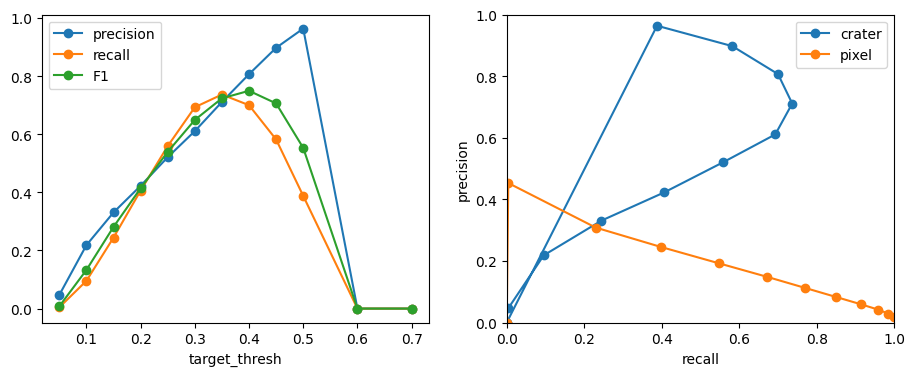

best threshold: 0.4   F1 0.750


In [40]:
# DeepMoon's 0.1 assumes unweighted BCE. focal sits lower - notes 17.3

thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7]

sweep_rng = np.random.default_rng(params['seed'])
sweep_idx = np.sort(sweep_rng.choice(val_idx, size=params['n_sweep'], replace=False))

sweep_pred = []
sweep_truth = []
sweep_mask = []
sweep_large = []

for patch_idx in sweep_idx:

    sweep_pred.append(model.predict(patchInput(patch_idx)[None, ...], verbose=0)[0, :, :, 0])
    sweep_truth.append(patchTruth(patch_idx))
    sweep_mask.append(patchMask(patch_idx) > 0)
    sweep_large.append(patchLarge(patch_idx))

sweep_precision = []
sweep_recall = []
sweep_f1 = []

pixel_sweep_precision = []
pixel_sweep_recall = []

for threshold in thresholds:

    swept_match = 0
    swept_detected = 0
    swept_truth = 0

    swept_pixel_tp = 0
    swept_pixel_fp = 0
    swept_pixel_fn = 0

    for prediction, truth, true_rim, large in zip(sweep_pred, sweep_truth, sweep_mask, sweep_large):

        predicted_rim = prediction >= threshold
        both = (predicted_rim & true_rim).sum()

        swept_pixel_tp += both
        swept_pixel_fp += predicted_rim.sum() - both
        swept_pixel_fn += true_rim.sum() - both

        detections = filter_edge_craters(template_match_t(prediction.copy(), target_thresh=threshold))
        match_count, detection_count, truth_count, _, false_positives, _ = match_coords(truth, detections)

        excluded = matchesExcludedCrater(false_positives, large).sum()

        swept_match += match_count
        swept_detected += detection_count - excluded
        swept_truth += truth_count

    sweep_precision.append(safeDivide(swept_match, swept_detected))
    sweep_recall.append(safeDivide(swept_match, swept_truth))
    sweep_f1.append(safeDivide(2 * sweep_precision[-1] * sweep_recall[-1],
                               sweep_precision[-1] + sweep_recall[-1]))

    pixel_sweep_precision.append(safeDivide(swept_pixel_tp, swept_pixel_tp + swept_pixel_fp))
    pixel_sweep_recall.append(safeDivide(swept_pixel_tp, swept_pixel_tp + swept_pixel_fn))

    print(f'threshold {threshold}: P {sweep_precision[-1]:.3f}  R {sweep_recall[-1]:.3f}  F1 {sweep_f1[-1]:.3f}   | pixel P {pixel_sweep_precision[-1]:.3f}  R {pixel_sweep_recall[-1]:.3f}')


best_threshold = thresholds[int(np.argmax(sweep_f1))]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(thresholds, sweep_precision, marker='o', label='precision')
axes[0].plot(thresholds, sweep_recall, marker='o', label='recall')
axes[0].plot(thresholds, sweep_f1, marker='o', label='F1')
axes[0].set_xlabel('target_thresh')
axes[0].legend()

# the gap between the curves is what extraction costs
axes[1].plot(sweep_recall, sweep_precision, marker='o', label='crater')
axes[1].plot(pixel_sweep_recall, pixel_sweep_precision, marker='o', label='pixel')
axes[1].set_xlabel('recall')
axes[1].set_ylabel('precision')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.show()

print(f'best threshold: {best_threshold}   F1 {max(sweep_f1):.3f}')

## Crater-level metrics

In [41]:

rng = np.random.default_rng(params['seed'])

# sorted so patches from one npz are consecutive
eval_idx = np.sort(rng.choice(test_idx, size=params['n_eval'], replace=False))

total_match = 0
total_detected = 0
total_truth = 0
total_multi_match = 0
total_excluded = 0

all_matched_pairs = []
all_false_positives = []
all_excluded_fps = []
all_truth_radii = []

pixel_tp = 0
pixel_fp = 0
pixel_fn = 0
pixel_tn = 0

for patch_idx in eval_idx:

    prediction = model.predict(patchInput(patch_idx)[None, ...], verbose=0)
    detections = filter_edge_craters(template_match_t(prediction[0, :, :, 0].copy(), target_thresh=best_threshold))
    truth = patchTruth(patch_idx)

    predicted_rim = prediction[0, :, :, 0] >= best_threshold
    true_rim = patchMask(patch_idx) > 0

    both = (predicted_rim & true_rim).sum()

    pixel_tp += both
    pixel_fp += predicted_rim.sum() - both
    pixel_fn += true_rim.sum() - both
    pixel_tn += predicted_rim.size - predicted_rim.sum() - true_rim.sum() + both

    match_count, detection_count, truth_count, matched_pairs, false_positives, multi_match_count = match_coords(truth, detections)

    # excluded entirely, neither TP nor FP. notes 18.4
    if len(false_positives) > 0:
        explained = matchesExcludedCrater(false_positives, patchLarge(patch_idx))

        if explained.any():
            all_excluded_fps.append(false_positives[explained])

        false_positives = false_positives[~explained]
        total_excluded += int(explained.sum())
        detection_count -= int(explained.sum())

    total_match += match_count
    total_detected += detection_count
    total_truth += truth_count
    total_multi_match += multi_match_count

    if len(matched_pairs) > 0:
        all_matched_pairs.append(matched_pairs)

    if len(false_positives) > 0:
        all_false_positives.append(false_positives)

    if len(truth) > 0:
        all_truth_radii.append(truth[:, 2])

all_matched_pairs = stackOrEmpty(all_matched_pairs, 6)
all_false_positives = stackOrEmpty(all_false_positives, 3)
all_excluded_fps = stackOrEmpty(all_excluded_fps, 3)
all_truth_radii = np.concatenate(all_truth_radii) if all_truth_radii else np.empty(0)

print(f'TP: {total_match}   detected: {total_detected}   truth: {total_truth}')
print(f'detections >1 truth crater: {total_multi_match}')
print(f'detections >= 10 km craters: {total_excluded}')

TP: 29813   detected: 37126   truth: 42025
detections >1 truth crater: 544
detections >= 10 km craters: 266


In [42]:
# Crater-level metrics - the headline, as DeepMoon reports (2.6)
precision = safeDivide(total_match, total_detected)
recall = safeDivide(total_match, total_truth)
f1 = safeDivide(2 * precision * recall, precision + recall)

pixel_precision = safeDivide(pixel_tp, pixel_tp + pixel_fp)
pixel_recall = safeDivide(pixel_tp, pixel_tp + pixel_fn)
dice = safeDivide(2 * pixel_precision * pixel_recall, pixel_precision + pixel_recall)
iou = safeDivide(pixel_tp, pixel_tp + pixel_fp + pixel_fn)

print(f'crater  P {precision:.3f}   R {recall:.3f}   F1 {f1:.3f}')
print(f'pixel   P {pixel_precision:.3f}   R {pixel_recall:.3f}   Dice {dice:.3f}   IoU {iou:.3f}')

# logged to the training run so the nine runs can be compared in one place
with mlflow.start_run(run_id=run_id):
    mlflow.log_metric('precision', precision)
    mlflow.log_metric('recall', recall)
    mlflow.log_metric('f1', f1)
    mlflow.log_metric('multi_match', total_multi_match)
    mlflow.log_metric('target_thresh', best_threshold)
    mlflow.log_metric('pixel_precision', pixel_precision)
    mlflow.log_metric('pixel_recall', pixel_recall)
    mlflow.log_metric('pixel_dice', dice)
    mlflow.log_metric('pixel_iou', iou)

crater  P 0.803   R 0.709   F1 0.753
pixel   P 0.195   R 0.578   Dice 0.291   IoU 0.170


,level,P,R,F1,TP,detected,truth
0,crater,0.803,0.709,0.753,29813,37126,42025
1,pixel,0.195,0.578,0.291,1219959,6265558,2112063


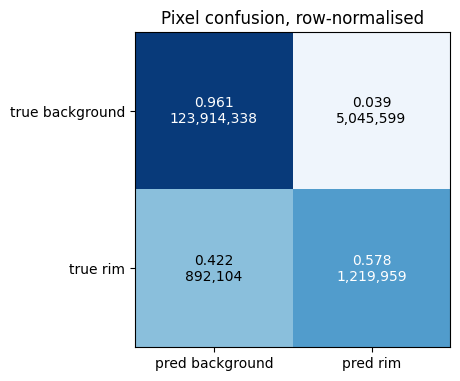

In [43]:
# Results summary

summary = pd.DataFrame([
    {'level': 'crater', 'P': precision, 'R': recall, 'F1': f1,
     'TP': int(total_match), 'detected': int(total_detected), 'truth': int(total_truth)},
    {'level': 'pixel', 'P': pixel_precision, 'R': pixel_recall, 'F1': dice,
     'TP': int(pixel_tp), 'detected': int(pixel_tp + pixel_fp), 'truth': int(pixel_tp + pixel_fn)},
])

display(summary.round(3))

confusion = np.array([[pixel_tn, pixel_fp], [pixel_fn, pixel_tp]], dtype=float)
normalised = confusion / confusion.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(normalised, cmap='Blues', vmin=0, vmax=1)

for i in range(2):

    for j in range(2):

        if normalised[i, j] > 0.5:
            colour = 'white'
        else:
            colour = 'black'

        ax.text(j, i, f'{normalised[i, j]:.3f}\n{int(confusion[i, j]):,}',
                ha='center', va='center', color=colour)

ax.set_xticks([0, 1], ['pred background', 'pred rim'])
ax.set_yticks([0, 1], ['true background', 'true rim'])
ax.set_title('Pixel confusion, row-normalised')

plt.tight_layout()
plt.show()

## Visualisation

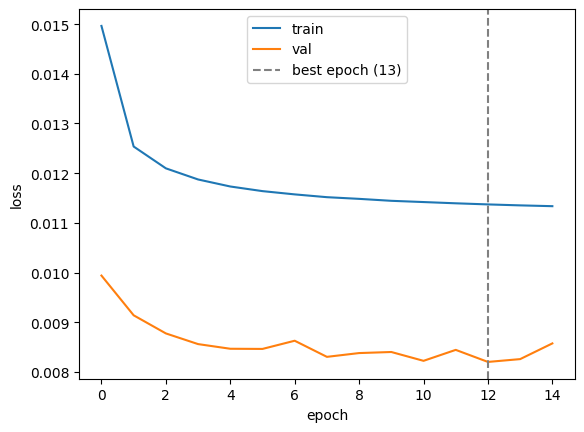

In [44]:
# Loss curves

curves = pd.read_csv(HISTORY_CSV)

best_epoch = int(curves['val_loss'].idxmin())

plt.plot(curves['loss'], label='train')
plt.plot(curves['val_loss'], label='val')
plt.axvline(best_epoch, color='grey', linestyle='--', label=f'best epoch ({best_epoch + 1})')

plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

5-10 px:  R 23654/32552   P 23641/30280
10-25 px:  R 5868/8698   P 5897/6558
25-50 px:  R 291/775   P 275/288


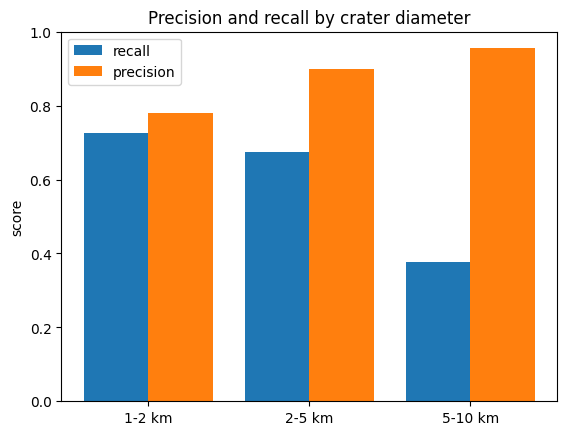

In [45]:
# Recall by crater diameter
# diameter_km = 2 * r_px * 0.1 -> 1-2 / 2-5 / 5-10 km are r = 5 / 10 / 25 / 50
# DeepMoon: recall drops above r = 15 px, 3 km here

bin_edges = [5, 10, 25, 50]
bin_labels = ['1-2 km', '2-5 km', '5-10 km']

matched_truth_radii = all_matched_pairs[:, 5]
matched_det_radii = all_matched_pairs[:, 2]
fp_radii = all_false_positives[:, 2]

bin_recall = []
bin_precision = []

for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):

    truth_in_bin = ((all_truth_radii >= lower) & (all_truth_radii < upper)).sum()
    matched_in_bin = ((matched_truth_radii >= lower) & (matched_truth_radii < upper)).sum()

    if truth_in_bin > 0:
        bin_recall.append(matched_in_bin / truth_in_bin)
    else:
        bin_recall.append(0)

    # precision bins by DETECTED radius, recall by truth radius
    det_in_bin = ((matched_det_radii >= lower) & (matched_det_radii < upper)).sum()
    fp_in_bin = ((fp_radii >= lower) & (fp_radii < upper)).sum()

    if det_in_bin + fp_in_bin > 0:
        bin_precision.append(det_in_bin / (det_in_bin + fp_in_bin))
    else:
        bin_precision.append(0)

    print(f'{lower}-{upper} px:  R {matched_in_bin}/{truth_in_bin}   P {det_in_bin}/{det_in_bin + fp_in_bin}')

x = np.arange(len(bin_labels))

plt.bar(x - 0.2, bin_recall, 0.4, label='recall')
plt.bar(x + 0.2, bin_precision, 0.4, label='precision')

plt.xticks(x, bin_labels)
plt.ylabel('score')
plt.ylim(0, 1)
plt.title('Precision and recall by crater diameter')
plt.legend()
plt.show()

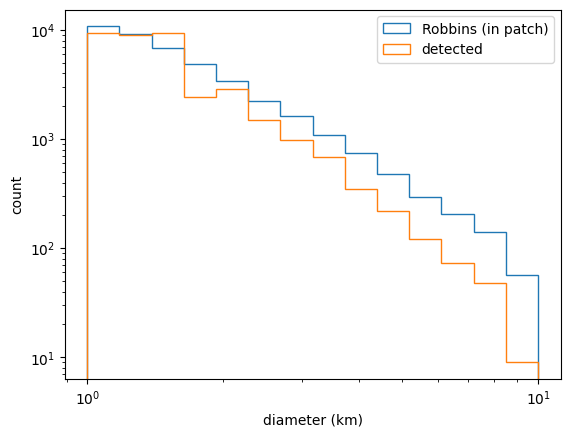

In [46]:
# Crater size-frequency distribution
# parallel to the catalogue -> extra detections behave like real craters

all_detected_radii = np.concatenate([all_matched_pairs[:, 2], all_false_positives[:, 2]])

detected_diameters = all_detected_radii * 2 * 0.1
truth_diameters = all_truth_radii * 2 * 0.1

diameter_bins = np.logspace(np.log10(1), np.log10(10), 15)

plt.hist(truth_diameters, bins=diameter_bins, histtype='step', label='Robbins (in patch)')
plt.hist(detected_diameters, bins=diameter_bins, histtype='step', label='detected')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('diameter (km)')
plt.ylabel('count')
plt.legend()
plt.show()

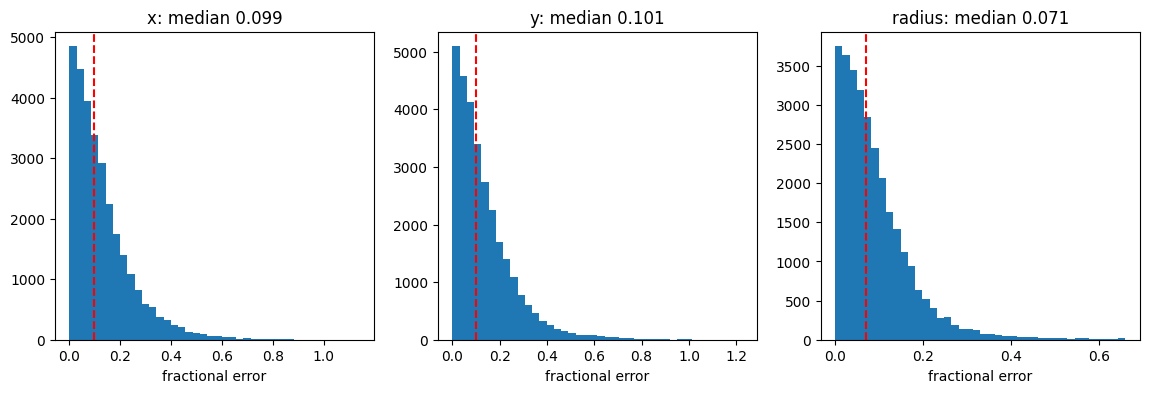

In [47]:
# Positional and radius error

mean_radius = (all_matched_pairs[:, 2] + all_matched_pairs[:, 5]) / 2

error_x = abs(all_matched_pairs[:, 0] - all_matched_pairs[:, 3]) / mean_radius
error_y = abs(all_matched_pairs[:, 1] - all_matched_pairs[:, 4]) / mean_radius
error_radius = abs(all_matched_pairs[:, 2] - all_matched_pairs[:, 5]) / mean_radius

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, values, name in zip(axes, [error_x, error_y, error_radius], ['x', 'y', 'radius']):

    ax.hist(values, bins=40)
    ax.axvline(np.median(values), color='red', linestyle='--')
    ax.set_title(f'{name}: median {np.median(values):.3f}')
    ax.set_xlabel('fractional error')

plt.show()

false positives:  7313
[[127 110   6]
 [150 228   5]
 [243  86   7]
 [235 222   5]
 [122  46   5]
 [ 90 208   8]
 [ 44 135   8]
 [153 231   5]
 [ 22 179   6]
 [239 236   7]
 [ 84 139   9]
 [154  53   5]]


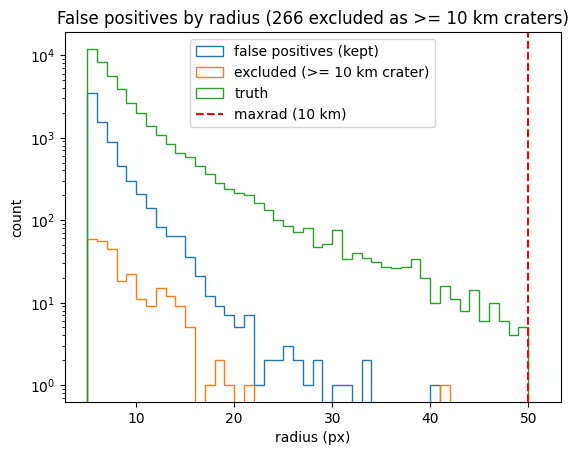

false positives at r >= 48 px: 0 of 7313 (0.0%)


In [48]:
# False positives
# Robbins incomplete near 1 km - some are real
# big ones on obvious craters are the >= 10 km label cut, not model error

n_show = 12

n_show = min(n_show, len(all_false_positives))
sample = all_false_positives[rng.choice(len(all_false_positives), n_show, replace=False)]

print('false positives: ', len(all_false_positives))
print(sample)


plt.hist(all_false_positives[:, 2], bins=np.arange(5, 52, 1), histtype='step', label='false positives (kept)')
plt.hist(all_excluded_fps[:, 2], bins=np.arange(5, 52, 1), histtype='step', label='excluded (>= 10 km crater)')
plt.hist(all_truth_radii, bins=np.arange(5, 52, 1), histtype='step', label='truth')

plt.axvline(50, color='red', linestyle='--', label='maxrad (10 km)')
plt.xlabel('radius (px)')
plt.ylabel('count')
plt.yscale('log')
plt.legend()
plt.title(f'False positives by radius ({total_excluded} excluded as >= 10 km craters)')
plt.show()

at_cap = (all_false_positives[:, 2] >= 48).sum()
print(f'false positives at r >= 48 px: {at_cap} of {len(all_false_positives)} ({at_cap/max(len(all_false_positives),1)*100:.1f}%)')

## Alignment check

WAC, stored mask and Robbins truth on one image - all derived independently. Rings on visible craters in both panels means the coordinate chain is sound.

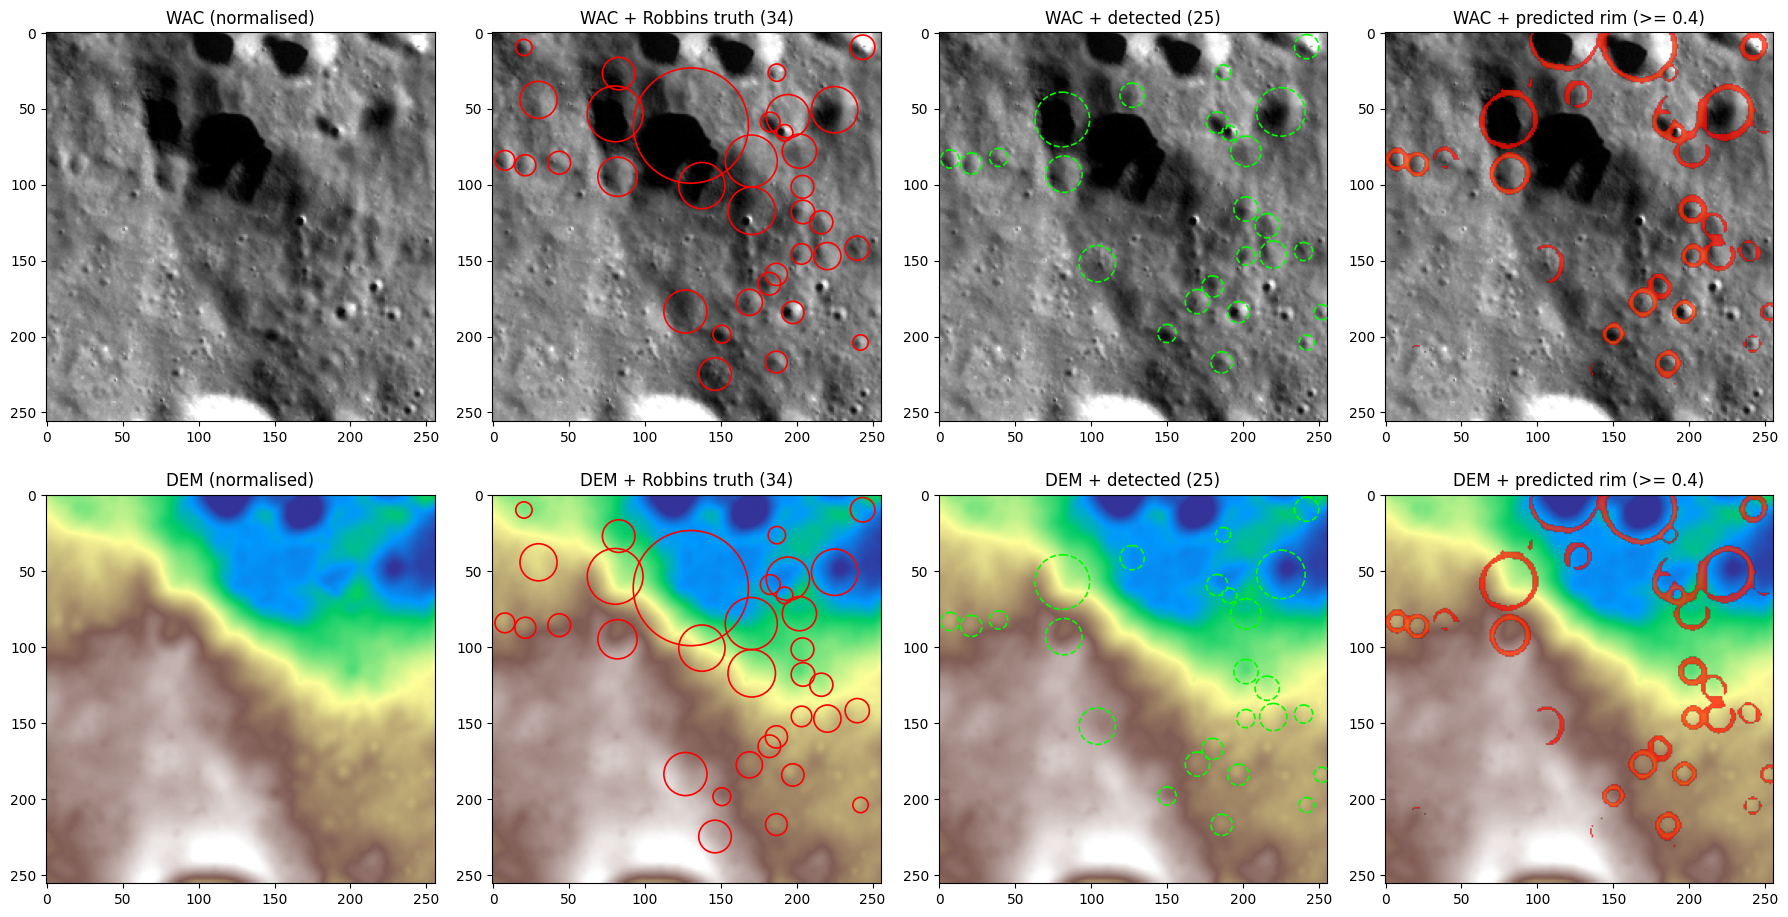

In [49]:
patch_idx = test_idx[0]

image = patchInput(patch_idx)
prediction = model.predict(image[None, ...], verbose=0)[0, :, :, 0]

truth = patchTruth(patch_idx)
detections = filter_edge_craters(template_match_t(prediction.copy(), target_thresh=best_threshold))

wac_patch = percentileNormalise(loaded['wac'][patch_idx % 1000])
dem_patch = percentileNormalise(loaded['dem'][patch_idx % 1000])

def drawCraters(ax, craters, colour, style='-'):

    for x, y, r in craters:
        ax.add_patch(plt.Circle((x, y), r, fill=False, color=colour, linewidth=1.2, linestyle=style))


fig, axes = plt.subplots(2, 4, figsize=(18, 9.4))

for row, (patch, name, cmap) in enumerate([(wac_patch, 'WAC', 'gray'), (dem_patch, 'DEM', 'terrain')]):

    axes[row, 0].imshow(patch, cmap=cmap)
    axes[row, 0].set_title(f'{name} (normalised)')

    axes[row, 1].imshow(patch, cmap=cmap)
    drawCraters(axes[row, 1], truth, 'red')
    axes[row, 1].set_title(f'{name} + Robbins truth ({len(truth)})')

    axes[row, 2].imshow(patch, cmap=cmap)
    drawCraters(axes[row, 2], detections, 'lime', '--')
    axes[row, 2].set_title(f'{name} + detected ({len(detections)})')

    # predicted rim pixels straight over the image, before template matching
    axes[row, 3].imshow(patch, cmap=cmap)
    axes[row, 3].imshow(np.ma.masked_where(prediction < best_threshold, prediction),
                        cmap='autumn', alpha=0.75, vmin=best_threshold, vmax=1)
    axes[row, 3].set_title(f'{name} + predicted rim (>= {best_threshold})')

plt.tight_layout()
plt.show()

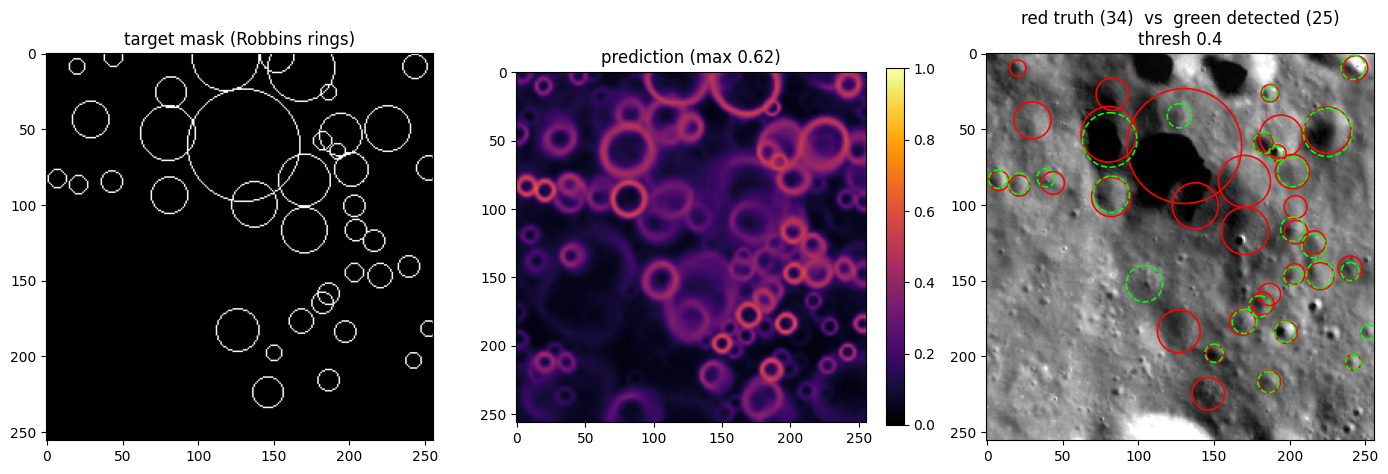

In [50]:
# the target it was trained against, and the raw sigmoid before any threshold
# focal loss compresses the output low - a dim map expected

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))

axes[0].imshow(patchMask(patch_idx), cmap='gray')
axes[0].set_title('target mask (Robbins rings)')

probability = axes[1].imshow(prediction, cmap='inferno', vmin=0, vmax=1)
axes[1].set_title(f'prediction (max {prediction.max():.2f})')
fig.colorbar(probability, ax=axes[1], fraction=0.046)

# red truth against green detected, on the channel the model actually saw
axes[2].imshow(image[..., 0], cmap='gray')
drawCraters(axes[2], truth, 'red')
drawCraters(axes[2], detections, 'lime', '--')
axes[2].set_title(f'red truth ({len(truth)})  vs  green detected ({len(detections)})\n'
                  f'thresh {best_threshold}')

plt.tight_layout()
plt.show()